<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Soil-Kriging-Analysis/blob/main/kriging_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Spasial Kandungan Zinc Tanah Menggunakan Ordinary Kriging

# 1. Install Library



In [40]:
!pip install pykrige
!pip install scikit-gstat

# 2. Import Library
Library yang digunakan mencakup pengolahan data, visualisasi, pembuatan variogram, serta metode interpolasi Ordinary Kriging.

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from skgstat import Variogram

from pykrige.ok import OrdinaryKriging

from sklearn.metrics import mean_squared_error, mean_absolute_error

# 3. INPUT DATA

Data yang digunakan merupakan data kandungan unsur tanah. Pada penelitian ini hanya digunakan variabel Zinc sebagai objek analisis spasial dengan mempertimbangkan informasi koordinat lokasi pengamatan.

In [42]:
from google.colab import files

uploaded = files.upload()

Saving soil.xlsx to soil (3).xlsx


In [43]:
data = pd.read_excel("soil.xlsx")

data.head()

,x,y,lead,zinc
0,181072,333611,299,1022
1,181025,333558,277,1141
2,181165,333537,199,640
3,181298,333484,116,257
4,181307,333330,117,269


# 4. PEMERIKSAAN DATA

Eksplorasi awal dilakukan untuk memahami karakteristik data sebelum pemodelan spasial dilakukan. Tahapan ini bertujuan mengetahui jumlah observasi, nilai statistik deskriptif, serta pola distribusi kandungan Zinc.

In [45]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   x       155 non-null    int64
 1   y       155 non-null    int64
 2   lead    155 non-null    int64
 3   zinc    155 non-null    int64
dtypes: int64(4)
memory usage: 5.0 KB


,x,y,lead,zinc
count,155.000000,155.000000,155.000000,155.000000
mean,180004.600000,331634.935484,153.361290,469.716129
std,746.039775,1047.746801,111.320054,367.073788
min,178605.000000,329714.000000,37.000000,113.000000
25%,179371.000000,330762.000000,72.500000,198.000000
50%,179991.000000,331633.000000,123.000000,326.000000
75%,180629.500000,332463.000000,207.000000,674.500000
max,181390.000000,333611.000000,654.000000,1839.000000


# 5. PEMILIHAN VARIABEL

In [46]:
x = data["x"].values

y = data["y"].values

zinc = data["zinc"].values

# 6. EXPLORATORY DATA ANALYSIS ZINC

Analisis eksplorasi dilakukan untuk melihat karakteristik distribusi kandungan Zinc. Histogram digunakan untuk melihat bentuk distribusi data, sedangkan boxplot digunakan untuk mendeteksi keberadaan pencilan.

Berdasarkan hasil eksplorasi, apabila data menunjukkan pola menceng ke kanan (right skewed) dan terdapat outlier, maka diperlukan transformasi data sebelum analisis variogram.

# Histogram

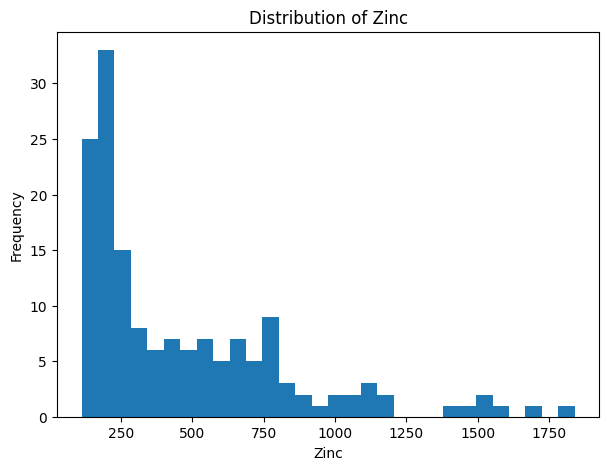

In [47]:
plt.figure(figsize=(7,5))


plt.hist(
    zinc,
    bins=30
)


plt.xlabel("Zinc")

plt.ylabel("Frequency")

plt.title(
    "Distribution of Zinc"
)


plt.show()

# Boxplot

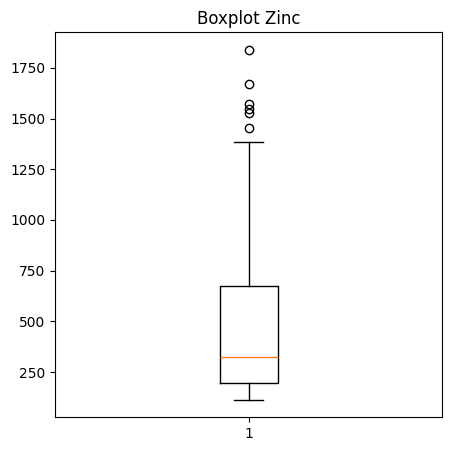

In [48]:
plt.figure(figsize=(5,5))


plt.boxplot(zinc)


plt.title(
    "Boxplot Zinc"
)


plt.show()

# 7. TRANSFORMASI LOGARITMA

Berdasarkan hasil eksplorasi, data Zinc menunjukkan adanya kemencengan distribusi dan beberapa nilai ekstrem. Oleh karena itu dilakukan transformasi logaritma natural untuk mengurangi pengaruh pencilan serta menstabilkan varians data.

In [49]:
zinc_log = np.log(zinc)

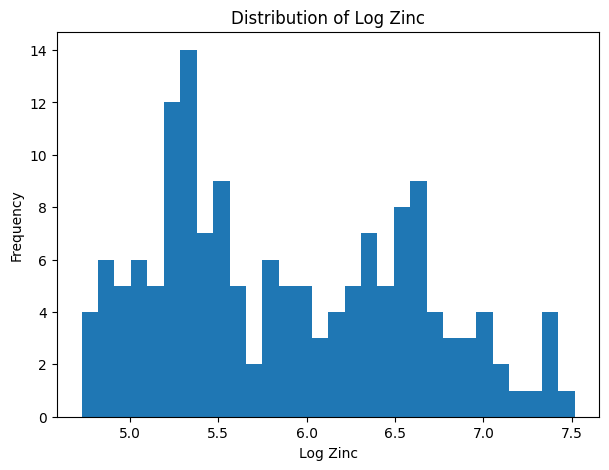

In [50]:
plt.figure(figsize=(7,5))


plt.hist(
    zinc_log,
    bins=30
)


plt.xlabel("Log Zinc")

plt.ylabel("Frequency")


plt.title(
    "Distribution of Log Zinc"
)


plt.show()

# 8. VISUALISASI LOKASI SAMPEL

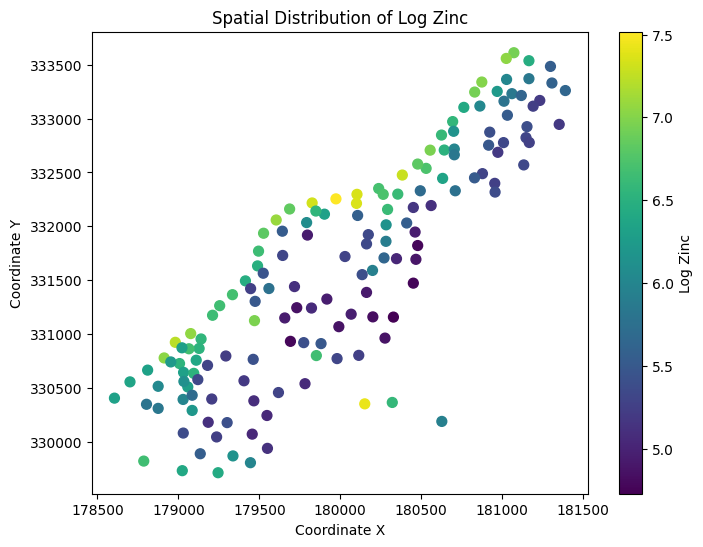

In [51]:
plt.figure(figsize=(8,6))


plt.scatter(
    x,
    y,
    c=zinc_log,
    cmap="viridis",
    s=50
)


plt.colorbar(
    label="Log Zinc"
)


plt.xlabel("Coordinate X")

plt.ylabel("Coordinate Y")


plt.title(
    "Spatial Distribution of Log Zinc"
)


plt.show()

# 9. EXPERIMENTAL VARIOGRAM

Variogram digunakan untuk mengukur hubungan spasial antar lokasi pengamatan berdasarkan jarak antar titik.

Experimental variogram menggambarkan perubahan tingkat keragaman nilai Zinc terhadap peningkatan jarak. Semakin dekat jarak antar lokasi, nilai yang diamati diharapkan memiliki kemiripan yang lebih tinggi.

In [52]:
coords = np.column_stack(
    (x,y)
)


V = Variogram(
    coords,
    zinc_log,
    n_lags=15,
    normalize=False
)


distance = V.bins


semivariance = V.experimental

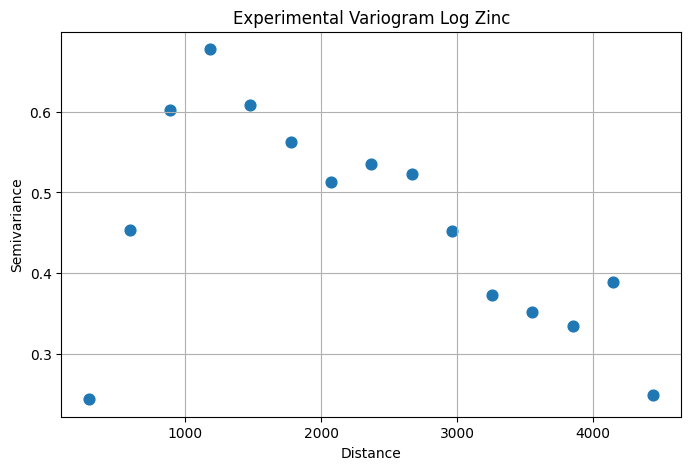

In [53]:
plt.figure(figsize=(8,5))


plt.scatter(
    distance,
    semivariance,
    s=60
)


plt.xlabel(
    "Distance"
)


plt.ylabel(
    "Semivariance"
)


plt.title(
    "Experimental Variogram Log Zinc"
)


plt.grid()


plt.show()

# 10. FITTING MODEL VARIOGRAM

Experimental variogram kemudian didekati menggunakan beberapa model teoritis untuk memperoleh model yang paling sesuai.

In [54]:
models = [
    "spherical",
    "exponential",
    "gaussian"
]


results={}

In [55]:
for model in models:


    OK_temp = OrdinaryKriging(

        x,
        y,
        zinc_log,

        variogram_model=model,

        verbose=False

    )


    results[model] = (
        OK_temp
        .variogram_model_parameters
    )


    print(
        "\nModel:",
        model
    )


    print(
        "Parameter:",
        results[model]
    )


Model: spherical
Parameter: [2.20007587e-01 6.93678899e+02 2.57100251e-01]

Model: exponential
Parameter: [4.75975368e-01 4.67074607e+02 3.55846806e-12]

Model: gaussian
Parameter: [4.62637890e-01 4.99603289e+02 1.44694347e-02]


# 11. VISUALISASI FITTING VARIOGRAM

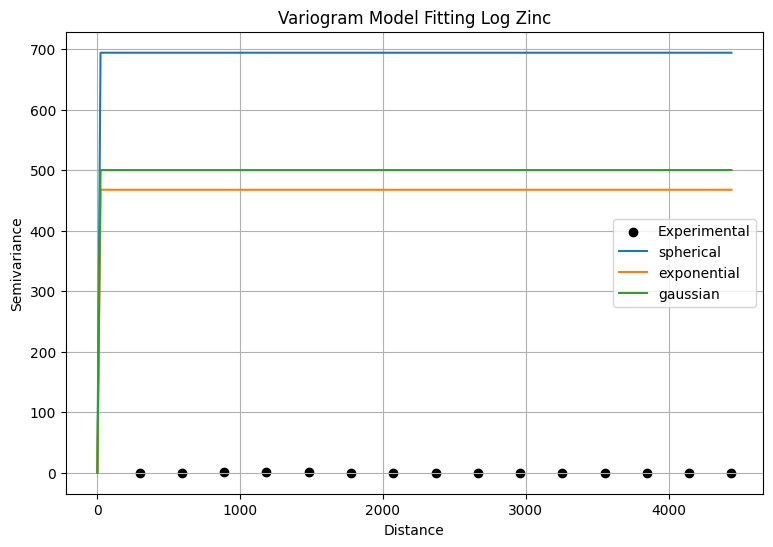

In [56]:
plt.figure(figsize=(9,6))


plt.scatter(
    distance,
    semivariance,
    color="black",
    label="Experimental"
)



h = np.linspace(
    0,
    max(distance),
    200
)



for model in models:


    params = results[model]


    nugget = params[0]

    sill = params[1]

    rang = params[2]



    if model=="spherical":


        gamma = np.where(

            h <= rang,

            nugget+sill*
            (
                1.5*(h/rang)
                -
                0.5*(h/rang)**3
            ),

            nugget+sill
        )


    elif model=="exponential":


        gamma = (
            nugget+
            sill*
            (
                1-np.exp(-h/rang)
            )
        )


    else:


        gamma = (
            nugget+
            sill*
            (
                1-np.exp(-(h/rang)**2)
            )
        )


    plt.plot(
        h,
        gamma,
        label=model
    )


plt.xlabel(
    "Distance"
)


plt.ylabel(
    "Semivariance"
)


plt.title(
    "Variogram Model Fitting Log Zinc"
)


plt.legend()

plt.grid()

plt.show()

# 12. CROSS VALIDATION MODEL

In [63]:

# KONVERSI TIPE DATA KOORDINAT
x = x.astype(float)

y = y.astype(float)

zinc_log = zinc_log.astype(float)


print(x.dtype)
print(y.dtype)
print(zinc_log.dtype)

float64
float64
float64


In [64]:

# CROSS VALIDATION MODEL VARIOGRAM


evaluation = {}


for model in models:

    print("Evaluating model:", model)


    predictions = []

    observations = []


    for i in range(len(zinc_log)):


        # data training
        x_train = np.delete(x,i)
        y_train = np.delete(y,i)
        z_train = np.delete(zinc_log,i)


        # model kriging
        OK_cv = OrdinaryKriging(

            x_train,
            y_train,
            z_train,

            variogram_model=model,

            verbose=False

        )


        # prediksi titik yang dihilangkan

        pred, ss = OK_cv.execute(

            "points",

            [x[i]],

            [y[i]]

        )


        predictions.append(
            pred[0]
        )


        observations.append(
            zinc_log[i]
        )



    RMSE = np.sqrt(

        mean_squared_error(

            observations,

            predictions

        )

    )


    MAE = mean_absolute_error(

        observations,

        predictions

    )


    Bias = np.mean(

        np.array(predictions)
        -
        np.array(observations)

    )


    evaluation[model]=[

        RMSE,

        MAE,

        Bias

    ]


    print(
        "RMSE:",
        RMSE
    )

    print(
        "MAE:",
        MAE
    )

    print(
        "Bias:",
        Bias
    )


Evaluating model: spherical
RMSE: 0.4472749617417646
MAE: 0.35711463500149565
Bias: 0.0009713753057185625
Evaluating model: exponential
RMSE: 0.4339274688829113
MAE: 0.3395639886030749
Bias: 0.003790660461783343
Evaluating model: gaussian
RMSE: 2.4133477267202856
MAE: 1.1007091818842853
Bias: -0.029912660659105486


# 13. TABEL EVALUASI MODEL

Evaluasi dilakukan untuk menentukan model variogram terbaik berdasarkan kemampuan prediksi.

Metode evaluasi menggunakan cross validation dengan beberapa ukuran kesalahan:

RMSE (Root Mean Square Error)
Mengukur rata-rata besar kesalahan prediksi.
MAE (Mean Absolute Error)
Mengukur rata-rata nilai absolut kesalahan.
Bias
Menunjukkan kecenderungan model melakukan overestimate atau underestimate.

Model dengan nilai RMSE dan MAE terkecil dipilih sebagai model terbaik.

In [65]:
evaluation_table=pd.DataFrame(

    evaluation,

    index=[
        "RMSE",
        "MAE",
        "Bias"
    ]

)


evaluation_table

,spherical,exponential,gaussian
RMSE,0.447275,0.433927,2.413348
MAE,0.357115,0.339564,1.100709
Bias,0.000971,0.003791,-0.029913


# 14. PEMILIHAN MODEL TERBAIK

Berdasarkan hasil evaluasi cross validation, model variogram terbaik dipilih untuk digunakan dalam proses Ordinary Kriging.

Pemilihan model dilakukan secara objektif berdasarkan nilai error terkecil.

In [66]:
best_model = (
    evaluation_table
    .loc["RMSE"]
    .idxmin()
)


print(
    "Model terbaik:",
    best_model
)

Model terbaik: exponential


# 15. ORDINARY KRIGING

Ordinary Kriging merupakan metode interpolasi spasial yang digunakan untuk memperkirakan nilai Zinc pada lokasi yang tidak memiliki pengamatan.

Prediksi dilakukan berdasarkan:

nilai pengamatan sekitar,
jarak antar lokasi,
struktur variogram terbaik.

In [67]:
OK = OrdinaryKriging(

    x,

    y,

    zinc_log,

    variogram_model=best_model,

    verbose=False

)

In [68]:
grid_x=np.linspace(
    min(x),
    max(x),
    200
)


grid_y=np.linspace(
    min(y),
    max(y),
    200
)

In [69]:
z_pred, ss = OK.execute(

    "grid",

    grid_x,

    grid_y

)

# 16. PETA PREDIKSI LOG ZINC

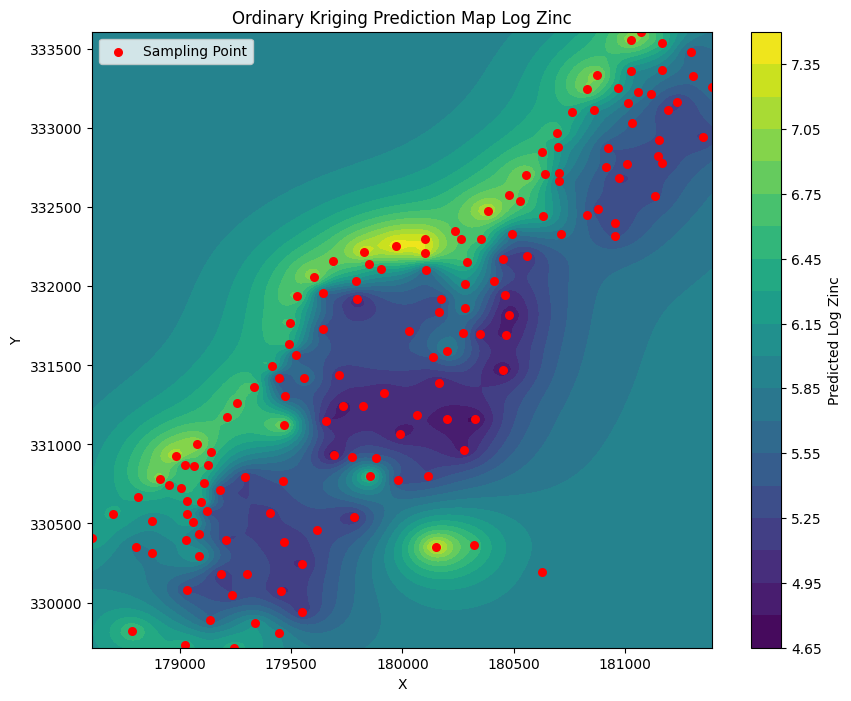

In [70]:
plt.figure(figsize=(10,8))


plt.contourf(

    grid_x,

    grid_y,

    z_pred,

    levels=20,

    cmap="viridis"

)


plt.colorbar(
    label="Predicted Log Zinc"
)



plt.scatter(

    x,

    y,

    c="red",

    s=30,

    label="Sampling Point"

)



plt.title(
    "Ordinary Kriging Prediction Map Log Zinc"
)


plt.xlabel("X")

plt.ylabel("Y")


plt.legend()

plt.show()

# 17. BACK TRANSFORMATION KE ZINC ASLI

Karena pemodelan variogram dan Ordinary Kriging dilakukan menggunakan data hasil transformasi logaritma, hasil prediksi perlu dikembalikan ke skala awal agar dapat diinterpretasikan dalam satuan Zinc asli.

In [71]:
zinc_prediction=np.exp(z_pred)

# 18. PETA AKHIR ZINC

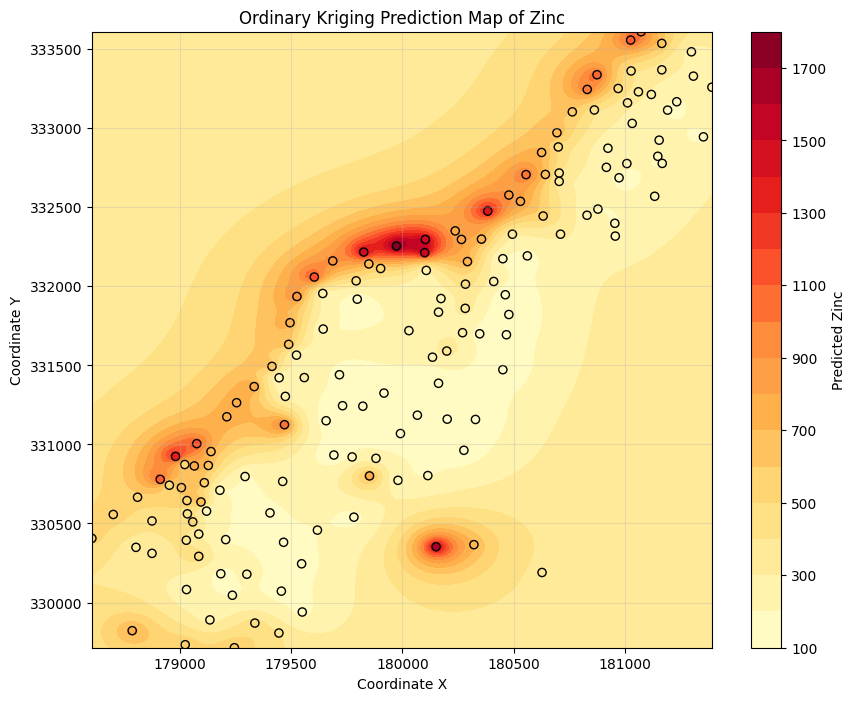

In [72]:
plt.figure(figsize=(10,8))


plt.contourf(

    grid_x,

    grid_y,

    zinc_prediction,

    levels=20,

    cmap="YlOrRd"

)


plt.colorbar(
    label="Predicted Zinc"
)



plt.scatter(

    x,

    y,

    c=zinc,

    cmap="YlOrRd",

    edgecolor="black",

    s=35

)



plt.xlabel("Coordinate X")

plt.ylabel("Coordinate Y")


plt.title(
    "Ordinary Kriging Prediction Map of Zinc"
)


plt.grid(alpha=0.3)


plt.show()